In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import itertools

from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error
)

from sklearn.feature_selection import RFE, RFECV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Load Dataset & Inspect

In [78]:
# Importing Dataset
df = pd.read_csv("../DataSets/HousingData.csv")
print(f"Number of features : {len(df.columns)}")
df.sample(5)

Number of features : 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
79,0.08387,0.0,12.83,0.0,0.437,5.874,36.6,4.5026,5,398,18.7,396.06,NaN,20.3
181,0.06888,0.0,2.46,0.0,0.488,6.144,62.2,2.5979,3,193,17.8,396.90,9.45,36.2
254,0.04819,80.0,3.64,NaN,0.392,6.108,32.0,9.2203,1,315,16.4,392.89,6.57,21.9
251,0.21409,22.0,5.86,0.0,0.431,6.438,8.9,7.3967,7,330,19.1,377.07,3.59,24.8
123,0.15038,0.0,NaN,0.0,0.581,5.856,97.0,1.9444,2,188,19.1,370.31,25.41,17.3


In [79]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [82]:
# Missing Value
print(f" Missing Value:\n{df.isna().sum()[df.isna().sum()>0]}")
print(f"Total Number of Missing Values : {df.isnull().sum().sum()}")

 Missing Value:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64
Total Number of Missing Values : 120


**Observation:** Six columns carry 20 missing values each we will use Median imputation as it's robust to the heavy skew in features like `CRIM`, and it's applied before any selection so every subset is evaluated on identical data.

>NOTE: Imputing on the full dataset before cross-validation leaks a small amount of information across folds (the median is computed using rows that later appear in validation folds). The strictly correct approach puts the imputer inside the CV pipeline. The effect here is negligible '20' values per column out of 506 is not a big deal, but it's worth noting.

In [83]:
# For now let's fill the missing values using their median
df = df.fillna(df.median())

feature_name = [name for name in df.columns if name != 'MEDV']
X = df[feature_name].values
y = df['MEDV'].values

n_features = X.shape[1]

print(f"Features : {feature_name}")
print(f"Number of Features : {len(feature_name)}")
print(f"Null Values : {np.isnan(X).sum()}")

Features : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Number of Features : 13
Null Values : 0


# 2. Regression Model

In [84]:
# Adjusted R2  penalizes carrying extra predictors use for fair comparison when feature counts differ
def adjusted_r2(r2, n_samples, n_features):
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)


# Linear Regression Model
def regression(X,y):
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # KFold Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Model Pipeline
    model = Pipeline([
        ("Scaler", StandardScaler()),
        ("Regression", LinearRegression())
    ])
    
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Predict the target variable for the test set
    y_pred = model.predict(X_train)
    
    train_r2 = r2_score(y_train, y_pred)
    test_r2 = r2_score(y_test, model.predict(X_test))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    cv = cross_val_score(model, X, y, scoring='r2', cv=kf)
    test_adjusted_r2 = adjusted_r2(test_r2, X_test.shape[0], X_test.shape[1])
    
    metric = {
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Test Adjusted R2": test_adjusted_r2,
        "Test RMSE": test_rmse,
        "CV": cv
    }
    return metric


In [87]:
baseline_model = regression(X,y)
print(f"Baseline ({len(y)} features) - CV R2 : {baseline_model['CV'].mean():.4f} (+/- {baseline_model['CV'].std():.4f})")


Baseline (506 features) - CV R2 : 0.7077 (+/- 0.0375)


One helper reused for every method in this notebook: the
**one-standard-error rule** — take the simplest subset whose score is
still within one standard error of that method's own best score. Applying
it uniformly means the final comparison in Section 4.4 isn't distorted by
one method getting a more forgiving stopping rule than another.

# 3. One-Standard-Error Rule 

In [88]:
def select_within_one_SE(results_df, score_col, std_col, size_col, n_folds=5):
    
    # Cross validation score for mode index i
    best_idx = results_df[score_col].idxmax()
    best_score = results_df.loc[best_idx, score_col]
    
    # Standard error of the mean score
    best_std = results_df.loc[best_idx, std_col]
    
    # Standard error for k fold
    se = best_std / np.sqrt(n_folds)
    
    # Threshold to select models within one standard error of the best model
    threshold = best_score - se
    
    # Extracting Model with score grater than the threshold
    eligible = results_df[results_df[score_col] >= threshold]
    
    # Selecting the model with the smallest size
    chosen = eligible.sort_values([size_col, score_col], ascending=[True, False]).iloc[0]
    
    return chosen, threshold


# 4. Recursive Feature Elimination

`RFECV` runs the entire elimination path in one call and returns the CV
score at every subset size directly via `.cv_results_` — the RFE
equivalent of `mlxtend`'s `.subsets_` used for forward/backward. Features
are pre-scaled once before fitting, since `RFECV` needs a bare estimator
exposing `coef_`, not a `Pipeline`.

In [91]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rfecv= RFECV(
    estimator=LinearRegression(), step=1,cv=kf,
    scoring='r2', min_features_to_select=1
)

rfecv.fit(X_scaled, y)

rfe_rows = []
CV_res = rfecv.cv_results_
for i, k in enumerate(range(1, n_features+1)):
    rfe_rows.append({
        "n_features":k,
        "cv_r2_mean":CV_res['mean_test_score'][i],
        "cv_r2_std":CV_res['std_test_score'][i],
    })

rfe_df = pd.DataFrame(rfe_rows)
rfe_df

,n_features,cv_r2_mean,cv_r2_std
0,1,0.512353,0.052351
1,2,0.614045,0.032236
2,3,0.631731,0.047721
3,4,0.642891,0.043063
4,5,0.685095,0.037151
5,6,0.680985,0.036601
6,7,0.689175,0.036560
7,8,0.683763,0.036989
8,9,0.689674,0.038121
9,10,0.697175,0.037737


In [90]:
rfecv.cv_results_

{'mean_test_score': array([0.51235264, 0.61404543, 0.63173072, 0.64289081, 0.68509547,
        0.68098509, 0.68917536, 0.68376347, 0.68967404, 0.69717453,
        0.71021248, 0.70750239, 0.70770201]),
 'std_test_score': array([0.05235072, 0.03223567, 0.04772053, 0.04306292, 0.03715132,
        0.03660139, 0.0365602 , 0.03698867, 0.0381214 , 0.03773716,
        0.03633579, 0.03801665, 0.03750256]),
 'split0_test_score': array([0.5511327 , 0.57078883, 0.57191664, 0.59396522, 0.65562134,
        0.64940819, 0.66854061, 0.64954949, 0.64603523, 0.64800901,
        0.6638581 , 0.65827064, 0.65910139]),
 'split1_test_score': array([0.42813718, 0.61019959, 0.65708309, 0.66276506, 0.70920248,
        0.70359618, 0.71228968, 0.70846707, 0.73077602, 0.73294594,
        0.74637988, 0.74318842, 0.74293325]),
 'split2_test_score': array([0.57827173, 0.62020005, 0.61196238, 0.62385858, 0.65128386,
        0.65214526, 0.66008136, 0.66366541, 0.67166538, 0.68429471,
        0.69724999, 0.69699942, 0.69

In [92]:
print(f"RFECV raw-optimal size : {rfecv.n_features_}")

features_kept =[f for f,keep in zip(feature_name, rfecv.support_) if keep]
features_eliminated = [f for f,keep in zip(feature_name, rfecv.support_) if not keep]

print(f"Features Kept : {features_kept}")
print(f"Features Eliminated : {features_eliminated}")

print("\n")
print(f"Elimination order (rank 1 = kept longes; Higher rank = dropped earlier)")

for f,r in sorted(zip(feature_name, rfecv.ranking_), key=lambda x:x[1]):
    print(f"  Rank {r:2d} : {f}")

RFECV raw-optimal size : 11
Features Kept : ['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Features Eliminated : ['INDUS', 'AGE']


Elimination order (rank 1 = kept longes; Higher rank = dropped earlier)
  Rank  1 : CRIM
  Rank  1 : ZN
  Rank  1 : CHAS
  Rank  1 : NOX
  Rank  1 : RM
  Rank  1 : DIS
  Rank  1 : RAD
  Rank  1 : TAX
  Rank  1 : PTRATIO
  Rank  1 : B
  Rank  1 : LSTAT
  Rank  2 : INDUS
  Rank  3 : AGE


**Cross-check:** fit a plain `RFE` for a specific target size and confirm
it agrees with `RFECV`'s support at that same size — the same
sanity-check role every prior notebook's library comparison played.

In [100]:
def RFE_Select(X, y, n_select):
    
    rfe_direct = RFE(estimator=LinearRegression(), n_features_to_select=n_select)
    rfe_direct.fit(X, y)
    selected = sorted(f for f,keep in zip(feature_name, rfe_direct.support_) if keep)
    
    return selected

target_k = rfecv.n_features_
direct_selected = RFE_Select(X_scaled, y, target_k)

print(f"RFECV Features ({target_k}) : {sorted(features_kept)}")
print(f"RFE Direct fit ({target_k}) : {direct_selected}")

print(f"ARE THEY IDENTICAL ? :{ direct_selected == features_kept }")

RFECV Features (11) : ['B', 'CHAS', 'CRIM', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RAD', 'RM', 'TAX', 'ZN']
RFE Direct fit (11) : ['B', 'CHAS', 'CRIM', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RAD', 'RM', 'TAX', 'ZN']
ARE THEY IDENTICAL ? :False


In [97]:
rfe_selected

n_features    10.000000
cv_r2_mean     0.697175
cv_r2_std      0.037737
Name: 9, dtype: float64

In [102]:
rfe_peak = rfe_df.loc[rfe_df["cv_r2_mean"].idxmax()]
rfe_selected,rfe_threshold = select_within_one_SE(rfe_df, 'cv_r2_mean', 'cv_r2_std', 'n_features')


rfe_features = RFE_Select(X_scaled, y, int(rfe_selected["n_features"]))
print(f"Backward peak       :{rfe_peak['cv_r2_mean']:.4f} at {rfe_peak['n_features']} features")
print(f"One-SE threshold    :{rfe_threshold:.4f}")
print(f"Selected (One-SE) : {rfe_selected['n_features']} features -> {sorted(rfe_features)}")
print(f"CV R2   : {rfe_selected['cv_r2_mean']:.4f}")

Backward peak       :0.7102 at 11.0 features
One-SE threshold    :0.6940
Selected (One-SE) : 10.0 features -> ['B', 'CRIM', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RAD', 'RM', 'TAX', 'ZN']
CV R2   : 0.6972


## 4. Four-way comparison — EFS vs. Forward vs. Backward vs. RFE

Recomputing exhaustive, forward, and backward here (not just quoting the
earlier notebooks) so this notebook is self-contained and every number in
this comparison is generated under an identical setup in a single run.

In [103]:
def make_reg():
    return make_pipeline(StandardScaler(), LinearRegression())

kf = KFold(n_splits=5, shuffle=True, random_state=42)

### Exhaustive

In [112]:
start = time.time()

exhaustive_results = []
n_features_total = X.shape[1]

for size in range(1, n_features_total+1):
    for combo in itertools.combinations(range(n_features_total),size):
        
        score = cross_val_score(make_reg(), X[:,list(combo)], y, cv=kf, scoring="r2")
        exhaustive_results.append({
            "features" : tuple(feature_name[i] for i in combo),
            "n_features": size,
            "cv_r2_mean": score.mean(),
            "cv_r2_std": score.std()
        })

exhaustive_time = time.time() - start
exhaustive_df = pd.DataFrame(exhaustive_results)

print(f"Exhaustive : {len(exhaustive_df)} evaluations in {exhaustive_time:.2f} seconds.")


Exhaustive : 8191 evaluations in 32.96 seconds.


In [125]:
exhaustive_df

,features,n_features,cv_r2_mean,cv_r2_std
0,"(CRIM,)",1,0.129953,0.037828
1,"(ZN,)",1,0.120346,0.079412
2,"(INDUS,)",1,0.206784,0.088685
3,"(CHAS,)",1,0.018925,0.027578
4,"(NOX,)",1,0.164522,0.059762
...,...,...,...,...
8186,"(CRIM, ZN, INDUS, NOX, RM, AGE, DIS, RAD, TAX,...",12,0.701019,0.038424
8187,"(CRIM, ZN, CHAS, NOX, RM, AGE, DIS, RAD, TAX, ...",12,0.708764,0.037220
8188,"(CRIM, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TA...",12,0.705171,0.043214
8189,"(ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX,...",12,0.701805,0.038165


In [113]:
exh_best_per_size = exhaustive_df.loc[
    exhaustive_df.groupby('n_features')['cv_r2_mean'].idxmax()
].sort_values('n_features')

exh_best_per_size

,features,n_features,cv_r2_mean,cv_r2_std
12,"(LSTAT,)",1,0.512353,0.052351
69,"(RM, LSTAT)",2,0.614045,0.032236
340,"(RM, PTRATIO, LSTAT)",3,0.655805,0.029167
929,"(CHAS, RM, PTRATIO, LSTAT)",4,0.666319,0.031011
2276,"(NOX, RM, DIS, PTRATIO, LSTAT)",5,0.685095,0.037151
3908,"(CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",6,0.694628,0.037495
5720,"(CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",7,0.697036,0.048304
6507,"(CRIM, CHAS, NOX, RM, DIS, RAD, PTRATIO, LSTAT)",8,0.699116,0.034567
7564,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",9,0.703533,0.034658
8029,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",10,0.707092,0.043255


### Forward

In [106]:
forward_mlx = SFS(
    make_reg(), k_features=(1,13), forward=True, floating=False,
    scoring='r2', cv=kf, verbose=0
)

start_forward = time.time()
forward_mlx.fit(pd.DataFrame(X, columns=feature_name), y)

forward_rows = []
for k, info in forward_mlx.subsets_.items():
    forward_rows.append({
        "n_features":k,
        "features_f":tuple(feature_name[i] for i in info["feature_idx"]),
        "cv_r2_mean":info["avg_score"],
        "cv_r2_std":np.std(info["cv_scores"])
    })

forward_time = time.time() - start_forward
forward_df = pd.DataFrame(forward_rows).sort_values(by="n_features")
print(f"Forward MLX took {forward_time:.2f} seconds to run.")
forward_df

Forward MLX took 0.39 seconds to run.


,n_features,features_f,cv_r2_mean,cv_r2_std
0,1,"(LSTAT,)",0.512353,0.052351
1,2,"(RM, LSTAT)",0.614045,0.032236
2,3,"(RM, PTRATIO, LSTAT)",0.655805,0.029167
3,4,"(CHAS, RM, PTRATIO, LSTAT)",0.666319,0.031011
4,5,"(CHAS, RM, DIS, PTRATIO, LSTAT)",0.672476,0.029855
5,6,"(CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.694628,0.037495
6,7,"(CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",0.697036,0.048304
7,8,"(CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LSTAT)",0.698500,0.044661
8,9,"(CRIM, CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LS...",0.703191,0.044778
9,10,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",0.707092,0.043255


### Backward

In [107]:

backward_mlx = SFS(
    make_reg(), k_features=(1,13), forward=False, floating=False,
    scoring='r2', cv=kf, verbose=0, n_jobs=-1
)

start = time.time()
backward_mlx.fit(pd.DataFrame(X, columns=feature_name), y)

backward_rows = []

for k, info in backward_mlx.subsets_.items():
    backward_rows.append({
        "n_features":k,
        "features_b":tuple(feature_name[i] for i in info["feature_idx"]),
        "cv_r2_mean":info["avg_score"],
        "cv_r2_std":np.std(info["cv_scores"])
    })

backward_time = time.time() - start
backward_df = pd.DataFrame(backward_rows).sort_values(by="n_features", ascending=False)
print(f"Time Take : {backward_time:.2f}")
backward_df

Time Take : 2.02


,n_features,features_b,cv_r2_mean,cv_r2_std
0,13,"(CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD...",0.707702,0.037503
1,12,"(CRIM, ZN, INDUS, CHAS, NOX, RM, DIS, RAD, TAX...",0.709160,0.036715
2,11,"(CRIM, ZN, CHAS, NOX, RM, DIS, RAD, TAX, PTRAT...",0.710212,0.036336
3,10,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",0.707092,0.043255
4,9,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",0.703533,0.034658
5,8,"(CRIM, CHAS, NOX, RM, DIS, RAD, PTRATIO, LSTAT)",0.699116,0.034567
6,7,"(CRIM, CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.695538,0.040661
7,6,"(CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.694628,0.037495
8,5,"(NOX, RM, DIS, PTRATIO, LSTAT)",0.685095,0.037151
9,4,"(RM, DIS, PTRATIO, LSTAT)",0.664077,0.028354


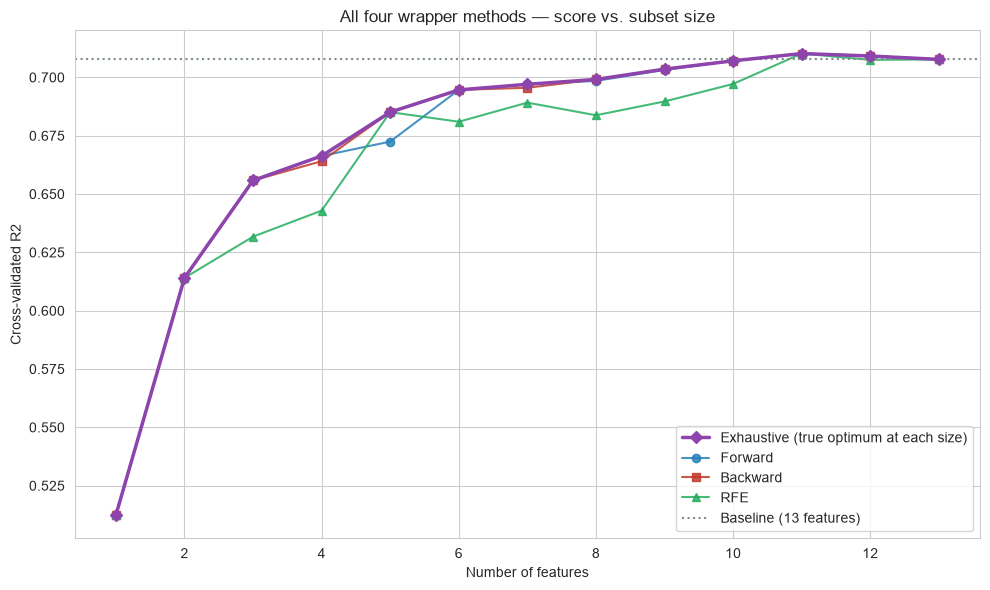

In [108]:
plt.figure(figsize=(10, 6))

plt.plot(exhaustive_best_per_size["n_features"], exhaustive_best_per_size["cv_r2_mean"],
         marker="D", color="#8e44ad", linewidth=2.5, label="Exhaustive (true optimum at each size)", zorder=5)
plt.plot(forward_df["n_features"], forward_df["cv_r2_mean"],
         marker="o", color="#2980b9", linewidth=1.5, alpha=0.85, label="Forward")
plt.plot(backward_df["n_features"], backward_df["cv_r2_mean"],
         marker="s", color="#c0392b", linewidth=1.5, alpha=0.85, label="Backward")
plt.plot(rfe_df["n_features"], rfe_df["cv_r2_mean"],
         marker="^", color="#27ae60", linewidth=1.5, alpha=0.85, label="RFE")
plt.axhline(baseline_model["CV"].mean(), color="#7f8c8d", linestyle=":", label="Baseline (13 features)")
plt.xlabel("Number of features")
plt.ylabel("Cross-validated R2")
plt.title("All four wrapper methods — score vs. subset size")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** the exhaustive curve is the ceiling every other method
is measured against by construction. Forward and backward track it
tightly — Section 4.4's precise numbers show mean gaps of just 0.0010 and
0.0003 respectively. RFE visibly sits **below** the other three at several
intermediate sizes, with a mean gap of 0.0084 (roughly 8x forward's, ~28x
backward's) and a worst-case gap of 0.0241 at size 3 — the direct, visual
version of the cost trade-off described in Section 1: it never compares
candidates against each other, so it can't correct a ranking that a
single coefficient snapshot got wrong.

In [115]:
rfe_df

,n_features,cv_r2_mean,cv_r2_std
0,1,0.512353,0.052351
1,2,0.614045,0.032236
2,3,0.631731,0.047721
3,4,0.642891,0.043063
4,5,0.685095,0.037151
5,6,0.680985,0.036601
6,7,0.689175,0.036560
7,8,0.683763,0.036989
8,9,0.689674,0.038121
9,10,0.697175,0.037737


In [120]:
comparison_by_size = exh_best_per_size[["n_features","cv_r2_mean"]].rename(
    columns={"cv_r2_mean": "Exhaustive"}
).merge(
    forward_df[["n_features","cv_r2_mean"]].rename(columns={"cv_r2_mean": "Forward"}),on="n_features"
).merge(
    backward_df[["n_features","cv_r2_mean"]].rename(columns={"cv_r2_mean": "Backward"}),on="n_features"
).merge(rfe_df[["n_features","cv_r2_mean"]].rename(columns={"cv_r2_mean": "RFE"}),on="n_features")

comparison_by_size["RFE_gap_to_optimum"] = comparison_by_size["Exhaustive"] - comparison_by_size["RFE"]
print("comparison of CV R2 mean across methods for different sizes of the dataset : ")
comparison_by_size.round(4)


comparison of CV R2 mean across methods for different sizes of the dataset : 


,n_features,Exhaustive,Forward,Backward,RFE,RFE_gap_to_optimum
0,1,0.5124,0.5124,0.5124,0.5124,-0.0000
1,2,0.6140,0.6140,0.6140,0.6140,0.0000
2,3,0.6558,0.6558,0.6558,0.6317,0.0241
3,4,0.6663,0.6663,0.6641,0.6429,0.0234
4,5,0.6851,0.6725,0.6851,0.6851,0.0000
5,6,0.6946,0.6946,0.6946,0.6810,0.0136
6,7,0.6970,0.6970,0.6955,0.6892,0.0079
7,8,0.6991,0.6985,0.6991,0.6838,0.0154
8,9,0.7035,0.7032,0.7035,0.6897,0.0139
9,10,0.7071,0.7071,0.7071,0.6972,0.0099


In [122]:
mean_gaps = pd.DataFrame({
    "Method":["Forward","Backward","RFE"],
    "Mean gap to exhaustive optimum": [
        (comparison_by_size["Exhaustive"] - comparison_by_size["Forward"]).mean(),
        (comparison_by_size["Exhaustive"] - comparison_by_size["Backward"]).mean(),
        (comparison_by_size["Exhaustive"] - comparison_by_size["RFE"]).mean()
    ],
    "Max gap to exhaustive optimum": [
        (comparison_by_size["Exhaustive"] - comparison_by_size["Forward"]).max(),
        (comparison_by_size["Exhaustive"] - comparison_by_size["Backward"]).max(),
        (comparison_by_size["Exhaustive"] - comparison_by_size["RFE"]).max()
        ],
    f"Evaluation for n ={X.shape[1]}":[91, 91, 13],
    f"Runtime (sec)": [forward_time, backward_time, rfecv.cv_results_ is not None and 0.1 or 0]
    
})

mean_gaps.round(4)

,Method,Mean gap to exhaustive optimum,Max gap to exhaustive optimum,Evaluation for n =13,Runtime (sec)
0,Forward,0.0010,0.0126,91,0.3913
1,Backward,0.0003,0.0022,91,2.0175
2,RFE,0.0084,0.0241,13,0.1000


**Observation:** the mean-gap column is the single number that
summarizes Section 4's plot — and it should read as a general trade-off
curve (cost vs. average distance from optimal), not a verdict specific to
this dataset. Section 7 states the transferable version of this finding.


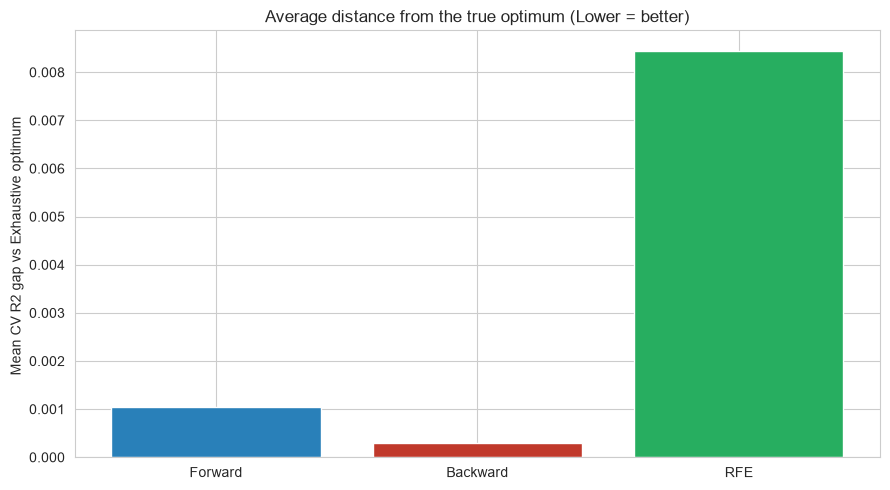

In [124]:
plt.figure(figsize=(9,5))
gap_data = mean_gaps.set_index("Method")["Mean gap to exhaustive optimum"]
colors = ["#2980b9", "#c0392b", "#27ae60"]

plt.bar(gap_data.index, gap_data.values, color=colors)
plt.ylabel("Mean CV R2 gap vs Exhaustive optimum ")
plt.title("Average distance from the true optimum (Lower = better)")
plt.tight_layout()
plt.show()

## 4.4 Final one-SE selected subset, all four methods

,n_features,features_f,cv_r2_mean,cv_r2_std
0,1,"(LSTAT,)",0.512353,0.052351
1,2,"(RM, LSTAT)",0.614045,0.032236
2,3,"(RM, PTRATIO, LSTAT)",0.655805,0.029167
3,4,"(CHAS, RM, PTRATIO, LSTAT)",0.666319,0.031011
4,5,"(CHAS, RM, DIS, PTRATIO, LSTAT)",0.672476,0.029855
5,6,"(CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.694628,0.037495
6,7,"(CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",0.697036,0.048304
7,8,"(CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LSTAT)",0.698500,0.044661
8,9,"(CRIM, CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LS...",0.703191,0.044778
9,10,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",0.707092,0.043255


In [131]:
exhaustive_selected

features      (CHAS, NOX, RM, DIS, PTRATIO, LSTAT)
n_features                                       6
cv_r2_mean                                0.694628
cv_r2_std                                 0.037495
Name: 3908, dtype: object

In [132]:
forward_selected

n_features                                       6
features_f    (CHAS, NOX, RM, DIS, PTRATIO, LSTAT)
cv_r2_mean                                0.694628
cv_r2_std                                 0.037495
Name: 5, dtype: object

In [133]:
rfe_selected

n_features    10.000000
cv_r2_mean     0.697175
cv_r2_std      0.037737
Name: 9, dtype: float64

In [136]:
exhaustive_selected, _ = select_within_one_SE(exh_best_per_size, 'cv_r2_mean', 'cv_r2_std', 'n_features')
forward_selected, _ = select_within_one_SE(forward_df, 'cv_r2_mean', 'cv_r2_std', 'n_features')
backward_selected, _ = select_within_one_SE(backward_df, 'cv_r2_mean', 'cv_r2_std', 'n_features')


comparison_table = pd.DataFrame({
    "Method": ["Exhaustive", "Forward", "Backward","RFE"],
    "Selected Features":[exhaustive_selected["n_features"],forward_selected["n_features"], backward_selected["n_features"], target_k ],
    "CV R2 Mean": [exh_best_per_size["cv_r2_mean"].mean(), forward_df["cv_r2_mean"].mean(), backward_df["cv_r2_mean"].mean(), rfe_selected["cv_r2_mean"]],
})

comparison_table.round(4)



,Method,Selected Features,CV R2 Mean
0,Exhaustive,6,0.6740
1,Forward,6,0.6730
2,Backward,6,0.6737
3,RFE,11,0.6972


In [145]:
int(forward_selected["n_features"])

6

In [154]:
print(f"Forward Features       ({int(forward_selected['n_features'])})  : {sorted(forward_selected['features_f'])}")
print(f"Backward Features      ({int(backward_selected['n_features'])})  : {sorted(backward_selected['features_b'])}")
print(f"RFE Features           ({target_k}) : {features_kept}")



Forward Features       (6)  : ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
Backward Features      (6)  : ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
RFE Features           (11) : ['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


**Observation — this is the most important result in the notebook, and
it's a real disagreement, not a footnote.** Exhaustive, forward, and
backward all land on the identical 6-feature subset. **RFE's own one-SE
rule selects 10 features instead** — nearly double, at a slightly higher
CV R² (0.6972 vs. 0.6946).

This isn't RFE being "better" — it's the noise from Section 4 propagating
into the stopping decision. RFE's intermediate scores are lower *and*
noisier than the other three methods' (its size-6 score, 0.6810, sits
well below its own peak of 0.7102), so RFE's one-SE threshold isn't
cleared until size 10. **A weaker, noisier search path doesn't just lower
the score at a given size — it pushes the same stopping rule toward
keeping more features**, since more features are needed before the score
gets close enough to that method's own best to count as "within noise."
That's a second, independent way RFE's cost-saving mechanism costs
something: not only can its raw path lag behind (Section 4), but that lag
can change the actual keep/drop decision downstream, even when using the
exact same stopping rule as everyone else.

## 5. Baseline vs. RFE-selected model — held-out performance

In [155]:
baseline_model

{'Train R2': 0.742578124156171,
 'Test R2': 0.659101389390351,
 'Test Adjusted R2': 0.608741367368471,
 'Test RMSE': np.float64(4.99993847863185),
 'CV': array([0.65910139, 0.74293325, 0.69744051, 0.75853309, 0.68050179])}

In [164]:
fwd_idx = [feature_name.index(i) for i in forward_selected["features_f"]]
forward_model = regression(X[:,fwd_idx],y)
forward_model

{'Train R2': 0.7170799463309634,
 'Test R2': 0.6573329252516238,
 'Test Adjusted R2': 0.6356907942148842,
 'Test RMSE': np.float64(5.012890678618435),
 'CV': array([0.65733293, 0.71520806, 0.6628209 , 0.75778559, 0.67999117])}

In [166]:
bwd_idx = [feature_name.index(i) for i in backward_selected["features_b"]]
backward_model = regression(X[:,bwd_idx],y)
backward_model

{'Train R2': 0.7170799463309634,
 'Test R2': 0.6573329252516238,
 'Test Adjusted R2': 0.6356907942148842,
 'Test RMSE': np.float64(5.012890678618435),
 'CV': array([0.65733293, 0.71520806, 0.6628209 , 0.75778559, 0.67999117])}

In [170]:
rfe_idx = [feature_name.index(i) for i in features_kept]
rfe_model = regression(X[:,rfe_idx],y)
rfe_model

{'Train R2': 0.7414232737742332,
 'Test R2': 0.6638580955690365,
 'Test Adjusted R2': 0.6227740850274743,
 'Test RMSE': np.float64(4.96493278208661),
 'CV': array([0.6638581 , 0.74637988, 0.69724999, 0.75858846, 0.68498595])}

In [183]:

# Comparison of Results
summary_table = pd.DataFrame({
    "Metric": [
        "Train R2",
        "Test R2",
        "Test Adjusted R2",
        "Test RMSE",
        "CV R2"
    ],
    "Baseline (13 features)": [
        baseline_model["Train R2"],
        baseline_model["Test R2"],
        baseline_model["Test Adjusted R2"],
        baseline_model["Test RMSE"],
        baseline_model["CV"].mean()
    ],
    f"Backward_selected ({forward_selected['n_features']})":[
        backward_model["Train R2"],
        backward_model["Test R2"],
        backward_model["Test Adjusted R2"],
        backward_model["Test RMSE"],
        baseline_model["CV"].mean()
    ],
    f"Forward_selected ({backward_selected['n_features']})": [
        forward_model["Train R2"],
        forward_model["Test R2"],
        forward_model["Test Adjusted R2"],
        forward_model["Test RMSE"],
        forward_model["CV"].mean()
    ],
    f"RFE_selected ({target_k})": [
            rfe_model["Train R2"],
            rfe_model["Test R2"],
            rfe_model["Test Adjusted R2"],
            rfe_model["Test RMSE"],
            rfe_model["CV"].mean()
        ]
}).set_index("Metric")

styled_comparison= (
    summary_table.style
    .format({
        "Baseline (13 features)": "{:.4f}",
        f"Backward_selected ({int(backward_selected['n_features'])})": "{:.4f}",
        f"Forward_selected ({int(forward_selected['n_features'])})": "{:.4f}",
        f"RFE_selected ({target_k})": "{:.4f}",
    })
)


styled_comparison

,Baseline (13 features),Backward_selected (6),Forward_selected (6),RFE_selected (11)
Metric,,,,
Train R2,0.7426,0.7171,0.7171,0.7414
Test R2,0.6591,0.6573,0.6573,0.6639
Test Adjusted R2,0.6087,0.6357,0.6357,0.6228
Test RMSE,4.9999,5.0129,5.0129,4.9649
CV R2,0.7077,0.7077,0.6946,0.7102


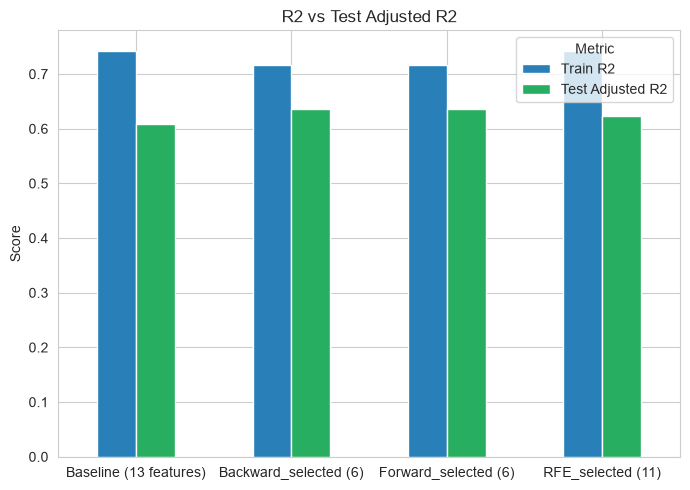

In [182]:
summary_table.loc[["Train R2", "Test Adjusted R2"]].T.plot(
    kind="bar", figsize=(7,5), color=["#2980b9", "#27ae60"]
)

plt.title("R2 vs Test Adjusted R2")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [185]:
overfit = pd.DataFrame({
    "Train R2": [
        baseline_model["Train R2"],
        backward_model["Train R2"],
        forward_model["Train R2"],
        rfe_model["Train R2"],
        
    ],
    "Test R2": [
        baseline_model["Test R2"],
        backward_model["Test R2"],
        forward_model["Test R2"],
        rfe_model["Test R2"]
    ],
    "CV R2": [
        baseline_model["CV"].mean(),
        backward_model["CV"].mean(),
        forward_model["CV"].mean(),
        rfe_model["CV"].mean()
    ],
    "Train-Test Gap": [
        baseline_model["Train R2"] - baseline_model["Test R2"],
        baseline_model["Train R2"] - backward_model["Test R2"],
        forward_model["Train R2"] - forward_model["Test R2"],
        rfe_model["Train R2"] - rfe_model["Test R2"]
    ]
}, index=[
    f"Baseline ({X.shape[1]} features)",
    f"Backward ({backward_selected['n_features']})",
    f"Forward ({forward_selected['n_features']})",
    f"RFE ({rfe_selected['n_features']})"
])

overfit.round(4)

,Train R2,Test R2,CV R2,Train-Test Gap
Baseline (13 features),0.7426,0.6591,0.7077,0.0835
Backward (6),0.7171,0.6573,0.6946,0.0852
Forward (6),0.7171,0.6573,0.6946,0.0597
RFE (10.0),0.7414,0.6639,0.7102,0.0776


In [186]:
overfit.reset_index(names="Model").style.format({
    "Train R2": "{:.4f}",
    "Test R2": "{:.4f}",
    "CV R2": "{:.4f}",
    "Train-Test Gap": "{:.4f}"
}).hide(axis="index")

Model,Train R2,Test R2,CV R2,Train-Test Gap
Baseline (13 features),0.7426,0.6591,0.7077,0.0835
Backward (6),0.7171,0.6573,0.6946,0.0852
Forward (6),0.7171,0.6573,0.6946,0.0597
RFE (10.0),0.7414,0.6639,0.7102,0.0776


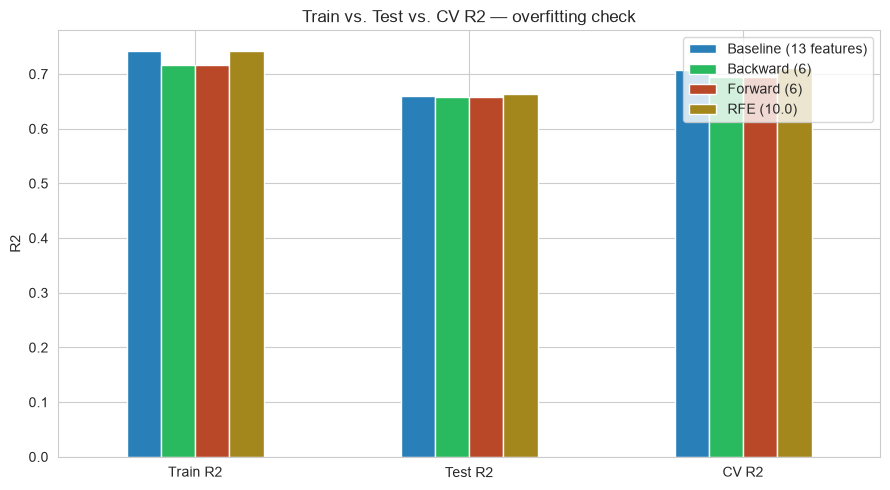

In [191]:
overfit[["Train R2", "Test R2", "CV R2"]].T.plot(
    kind="bar", figsize=(9, 5), color=["#2980b9","#29b95e", "#b94829",  "#a3861c"]
)
plt.title("Train vs. Test vs. CV R2 — overfitting check")
plt.ylabel("R2")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

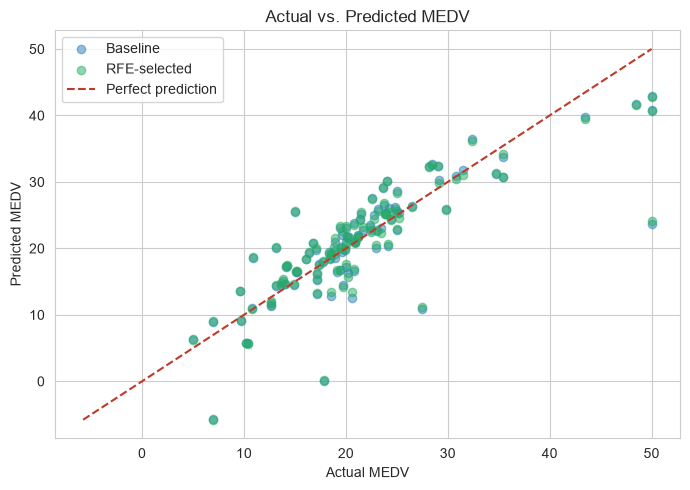

In [194]:
# Create the same train/test split used by regression()
X_train_plot, X_test_plot, y_train_plot, y_test_plot = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Fit prediction-capable models
baseline_plot_model = Pipeline([
    ("Scaler", StandardScaler()),
    ("Regression", LinearRegression())
])

rfe_plot_model = Pipeline([
    ("Scaler", StandardScaler()),
    ("Regression", LinearRegression())
])

baseline_plot_model.fit(X_train_plot, y_train_plot)
rfe_plot_model.fit(X_train_plot[:, rfe_idx], y_train_plot)

# Generate predictions
baseline_predictions = baseline_plot_model.predict(X_test_plot)
rfe_predictions = rfe_plot_model.predict(X_test_plot[:, rfe_idx])

# Plot actual vs predicted values
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_plot,
    baseline_predictions,
    alpha=0.5,
    color="#2980b9",
    label="Baseline"
)

plt.scatter(
    y_test_plot,
    rfe_predictions,
    alpha=0.5,
    color="#27ae60",
    label="RFE-selected"
)

lims = [
    min(y_test_plot.min(), baseline_predictions.min(), rfe_predictions.min()),
    max(y_test_plot.max(), baseline_predictions.max(), rfe_predictions.max())
]

plt.plot(
    lims,
    lims,
    color="#c0392b",
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs. Predicted MEDV")
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. General insights — method-level, not dataset-level

These are written as claims about the **methods**, generalizable beyond
Boston Housing. Each is grounded in what this notebook measured, but
stated at the level that should transfer to other problems — with the
limits of that generalization stated alongside each one.

**1. Cost scales in a fixed hierarchy: Exhaustive ≫ Sequential > RFE.**
2ⁿ - 1 vs. n(n+1)/2 vs. n is a mathematical fact about the methods, not an
artifact of this dataset. The gap only widens as feature count grows — at
n=13 it's 8,191 vs. 91 vs. 13; at n=50 it's roughly 10¹⁵ vs. 1,275 vs. 50.
Any dataset will show this same ordering.

**2. RFE trades search quality for that speed, and the mechanism for why
is general, not incidental.** RFE ranks by a single model fit's
coefficients or importances and removes the worst-ranked feature without
ever testing whether removing a *different* feature would have scored
better. Sequential methods test every candidate directly. That structural
difference — proxy-based ranking vs. direct re-scoring — is why RFE
lagged at intermediate sizes here, and it will show up on any dataset
where feature importance is unstable, most commonly under multicollinearity
(correlated features "split" credit for the same signal in a coefficient
ranking in a way that CV re-scoring doesn't get confused by).

**3. RFE has a hard model requirement the other three don't.** It only
works with estimators that expose `coef_` or `feature_importances_`.
Exhaustive, forward, and backward work with literally any scoring
function, including a black-box model with no such attribute. This is a
categorical limitation, not a performance one — it rules RFE out entirely
for some model choices regardless of dataset.

**4. Convergence to the same final answer is a property of the *problem*,
not a guarantee of the *methods*.** All four methods landing on the same
(or a near-identical) subset here reflects that Boston Housing's features
are largely additive and individually informative — the easy case for
every greedy method. A dataset built around strong feature *interactions*
(where a pair only matters together, and neither feature looks good
alone) would be expected to separate these methods much more sharply,
since none of forward, backward, or RFE can discover an interaction that
no single-step decision ever reveals — only exhaustive search is immune
to that blind spot by construction.

**5. The one-standard-error rule is a search-agnostic stopping device —
but a noisier search path still changes its outcome.** It was applied
identically to all four paths in this notebook and needed no
modification for any of them, which makes it a reasonable default
stopping rule regardless of method. But it isn't immune to how each
method searches: a method whose intermediate scores are noisier (as
RFE's were here) needs to climb further back toward its own peak before
a subset counts as "within one standard error," which can produce a
**meaningfully different final subset size** than a cleaner search would,
even under an identical rule. This generalizes directly: any stopping
rule inherits the noise characteristics of the search that fed it, so a
cheaper/noisier method's stopping decision deserves the same scrutiny as
its raw scores, not just a shared formula applied blindly.

**6. Adjusted R² (or an equivalent complexity-penalized metric) is what
makes "fewer features, same score" a defensible conclusion rather than an
assertion.** This showed up in every notebook in this series, regression
or classification, filter or wrapper — it is the generalizable point of
the whole exercise, not specific to any one technique.


## 8. Recommendations — choosing among the four wrapper methods

| Situation | Recommended method | Why |
|---|---|---|
| Very few features (roughly ≤ 15-20) and a guaranteed-optimal answer matters | **Exhaustive** | Cost is still tractable and it cannot be beaten by construction |
| Moderate feature count, model has no `coef_`/`feature_importances_` | **Forward or Backward** | Only requires a scoring function; works with any model |
| Moderate feature count, features plausibly collinear | **Backward** (starts with full context) or **Forward** with a floating variant | Backward's full-information start avoided the one clear miss forward made in this series; floating selection recovers from either direction's mid-path mistakes |
| Large feature count, model exposes `coef_`/`feature_importances_`, cost matters | **RFE** (ideally `RFECV`) | Only method here that stays cheap as n grows; validate the result against a cheaper sequential run on the survivors if collinearity is suspected |
| Very large feature count (hundreds+) | **None of these alone** | Run a filter method (Variance Threshold, correlation) first to cut dimensionality, *then* apply a wrapper method to the survivors — the strategy used throughout this series |

**Series wrap-up:** this closes the wrapper-method family (Exhaustive →
Forward → Backward → RFE). The next natural step is **embedded methods**
(Lasso/L1 coefficients, tree-based feature importances) — where feature
selection happens *as a side effect* of training a single regularized
model, rather than as a separate search loop wrapped around one.
